# Dataset 7: Basketball Free Throw Paradox

## Learning Objectives
- Compare classical statistics and Machine Gnostics on a small dataset.
- Practice mean, median, interval analysis, and errorbar interpretation.
- Use linear and polynomial regression to compare trend assumptions.
- Interpret where pooled analysis can fail and stratified structure matters.

## Citation
Workshop 3 curated NBA-style small sample with offensive-tier confounding.

## Why This Dataset Matters
A near-perfect aggregate sports correlation can mostly reflect team quality rather than causal leverage.

In [7]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import gaussian_kde

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('seaborn-v0_8')
np.set_printoptions(suppress=True)

## Step 1: Build The Dataset
Use the values curated in Workshop 3 to create a compact analysis table with:
- x_value: the primary predictor
- y_value: the response variable
- group: potential confounder or latent regime

In [8]:
records = [
    {'team': 'A', 'group': 'LowOffense', 'ft_pct': 71, 'wins': 28, 'ppg': 98},
    {'team': 'B', 'group': 'MidOffense', 'ft_pct': 74, 'wins': 35, 'ppg': 109},
    {'team': 'C', 'group': 'MidOffense', 'ft_pct': 78, 'wins': 41, 'ppg': 114},
    {'team': 'D', 'group': 'MidOffense', 'ft_pct': 80, 'wins': 45, 'ppg': 119},
    {'team': 'E', 'group': 'EliteOffense', 'ft_pct': 82, 'wins': 48, 'ppg': 123},
    {'team': 'F', 'group': 'EliteOffense', 'ft_pct': 85, 'wins': 50, 'ppg': 128},
    {'team': 'G', 'group': 'EliteOffense', 'ft_pct': 87, 'wins': 52, 'ppg': 132},
    {'team': 'H', 'group': 'EliteOffense', 'ft_pct': 90, 'wins': 55, 'ppg': 135},
]
df = pd.DataFrame(records)
df['x_value'] = df['ft_pct']
df['y_value'] = df['wins']
df['label'] = df['team']


df.head(), df.shape

(  team         group  ft_pct  wins  ppg  x_value  y_value label
 0    A    LowOffense      71    28   98       71       28     A
 1    B    MidOffense      74    35  109       74       35     B
 2    C    MidOffense      78    41  114       78       41     C
 3    D    MidOffense      80    45  119       80       45     D
 4    E  EliteOffense      82    48  123       82       48     E,
 (8, 8))

## Step 2: Classical Statistical Baseline
This section computes:
- mean and median
- Pearson correlation (overall and by group)
- linear and polynomial regression (degree 2)
- 95% confidence interval on the mean (error bars)

In [9]:
x = df['x_value'].to_numpy(dtype=float)
y = df['y_value'].to_numpy(dtype=float)

n = len(df)
mean_y = float(np.mean(y))
median_y = float(np.median(y))
std_y = float(np.std(y, ddof=1)) if n > 1 else 0.0
se_y = std_y / np.sqrt(max(n, 1))
ci_low = mean_y - 1.96 * se_y
ci_high = mean_y + 1.96 * se_y

if len(np.unique(x)) > 1:
    corr_all = float(np.corrcoef(x, y)[0, 1])
else:
    corr_all = np.nan

lin = LinearRegression().fit(x.reshape(-1, 1), y)
y_lin = lin.predict(x.reshape(-1, 1))

poly_deg = 2
poly_model = make_pipeline(PolynomialFeatures(degree=poly_deg, include_bias=False), LinearRegression())
poly_model.fit(x.reshape(-1, 1), y)
y_poly = poly_model.predict(x.reshape(-1, 1))

r2_lin = float(r2_score(y, y_lin))
r2_poly = float(r2_score(y, y_poly))
rmse_lin = float(np.sqrt(mean_squared_error(y, y_lin)))
rmse_poly = float(np.sqrt(mean_squared_error(y, y_poly)))

group_summary = (
    df.groupby('group')['y_value']
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
    .rename(columns={'mean': 'group_mean', 'median': 'group_median', 'std': 'group_std'})
)

within_corr = []
for g, gdf in df.groupby('group'):
    xg = gdf['x_value'].to_numpy(dtype=float)
    yg = gdf['y_value'].to_numpy(dtype=float)
    if len(gdf) > 2 and len(np.unique(xg)) > 1:
        c = float(np.corrcoef(xg, yg)[0, 1])
    else:
        c = np.nan
    within_corr.append({'group': g, 'corr_within_group': c, 'n': len(gdf)})
within_corr_df = pd.DataFrame(within_corr)

classical_metrics = pd.DataFrame([
    {'metric': 'n', 'value': n},
    {'metric': 'mean_y', 'value': mean_y},
    {'metric': 'median_y', 'value': median_y},
    {'metric': 'std_y', 'value': std_y},
    {'metric': 'corr_all', 'value': corr_all},
    {'metric': 'r2_linear', 'value': r2_lin},
    {'metric': 'r2_polynomial_deg2', 'value': r2_poly},
    {'metric': 'rmse_linear', 'value': rmse_lin},
    {'metric': 'rmse_polynomial_deg2', 'value': rmse_poly},
    {'metric': 'ci95_low_mean_y', 'value': ci_low},
    {'metric': 'ci95_high_mean_y', 'value': ci_high},
])

classical_metrics

,metric,value
0,n,8.000000
1,mean_y,44.250000
2,median_y,46.500000
3,std_y,9.130013
4,corr_all,0.982725
5,r2_linear,0.965747
6,r2_polynomial_deg2,0.996245
7,rmse_linear,1.580599
8,rmse_polynomial_deg2,0.523340
9,ci95_low_mean_y,37.923224


## Step 3: Machine Gnostics Analysis
This section computes Machine Gnostics equivalents for:
- robust mean and median
- robust correlation
- interval analysis (Typical and Tolerance intervals)
- linear and polynomial regression using Machine Gnostics models

In [10]:
mg_available = True
mg_error = None

try:
    from machinegnostics.magcal import ELDF, IntervalAnalysis
    from machinegnostics.models import LinearRegressor, PolynomialRegressor
    from machinegnostics.metrics import (
        mean as mg_mean,
        median as mg_median,
        correlation as mg_correlation,
        robr2,
        root_mean_squared_error,
    )
except Exception as exc:
    mg_available = False
    mg_error = str(exc)
    warnings.warn(f'Machine Gnostics import failed: {mg_error}')

if mg_available:
    mg_mean_y = float(mg_mean(y))
    mg_median_y = float(mg_median(y))
    try:
        mg_corr = float(mg_correlation(x, y))
    except Exception:
        mg_corr = np.nan

    ia = IntervalAnalysis(n_points=100, flush=False, verbose=False)
    ia.fit(y)
    ia_res = ia.results()

    mg_typ_low = float(ia_res['ZL'])
    mg_typ_high = float(ia_res['ZU'])
    mg_tol_low = float(ia_res['Z0L'])
    mg_tol_high = float(ia_res['Z0U'])

    mg_lin_model = LinearRegressor(max_iter=300, early_stopping=True, tolerance=1e-6, mg_loss='hi', history=True, verbose=False)
    mg_lin_model.fit(x, y)
    y_mg_lin = np.asarray(mg_lin_model.predict(x), dtype=float)
    mg_r2_lin = float(robr2(y, y_mg_lin, w=getattr(mg_lin_model, 'weights', None)))
    mg_rmse_lin = float(root_mean_squared_error(y, y_mg_lin))

    try:
        mg_poly_model = PolynomialRegressor(degree=2, max_iter=300, early_stopping=True, tolerance=1e-6, mg_loss='hi', history=True, verbose=False)
        mg_poly_model.fit(x, y)
        y_mg_poly = np.asarray(mg_poly_model.predict(x), dtype=float)
        mg_r2_poly = float(robr2(y, y_mg_poly, w=getattr(mg_poly_model, 'weights', None)))
        mg_rmse_poly = float(root_mean_squared_error(y, y_mg_poly))
    except Exception:
        y_mg_poly = np.full_like(y, fill_value=mg_mean_y, dtype=float)
        mg_r2_poly = np.nan
        mg_rmse_poly = np.nan

    mg_metrics = pd.DataFrame([
        {'metric': 'mg_mean_y', 'value': mg_mean_y},
        {'metric': 'mg_median_y', 'value': mg_median_y},
        {'metric': 'mg_corr', 'value': mg_corr},
        {'metric': 'mg_typical_low', 'value': mg_typ_low},
        {'metric': 'mg_typical_high', 'value': mg_typ_high},
        {'metric': 'mg_tolerance_low', 'value': mg_tol_low},
        {'metric': 'mg_tolerance_high', 'value': mg_tol_high},
        {'metric': 'mg_robr2_linear', 'value': mg_r2_lin},
        {'metric': 'mg_robr2_polynomial_deg2', 'value': mg_r2_poly},
        {'metric': 'mg_rmse_linear', 'value': mg_rmse_lin},
        {'metric': 'mg_rmse_polynomial_deg2', 'value': mg_rmse_poly},
    ])
else:
    mg_mean_y = np.nan
    mg_median_y = np.nan
    mg_corr = np.nan
    mg_typ_low = np.nan
    mg_typ_high = np.nan
    mg_tol_low = np.nan
    mg_tol_high = np.nan
    y_mg_lin = np.full_like(y, fill_value=np.nan, dtype=float)
    y_mg_poly = np.full_like(y, fill_value=np.nan, dtype=float)
    mg_metrics = pd.DataFrame([{'metric': 'Machine Gnostics availability', 'value': f'Not available: {mg_error}'}])

mg_metrics

,metric,value
0,mg_mean_y,47.170000
1,mg_median_y,46.414000
2,mg_corr,0.995091
3,mg_typical_low,37.511373
4,mg_typical_high,52.010654
5,mg_tolerance_low,42.632427
6,mg_tolerance_high,49.263853
7,mg_robr2_linear,0.999983
8,mg_robr2_polynomial_deg2,1.000000
9,mg_rmse_linear,0.504369


## Step 4: Visual Comparison (Plotting + Error Bars)
The 2x2 panel compares:
1. scatter + linear regression (classical vs Machine Gnostics)
2. scatter + polynomial regression (classical vs Machine Gnostics)
3. group-level means with standard error bars
4. interval analysis and distribution view (empirical CDF, ELDF CDF, KDE/ELDF PDF)

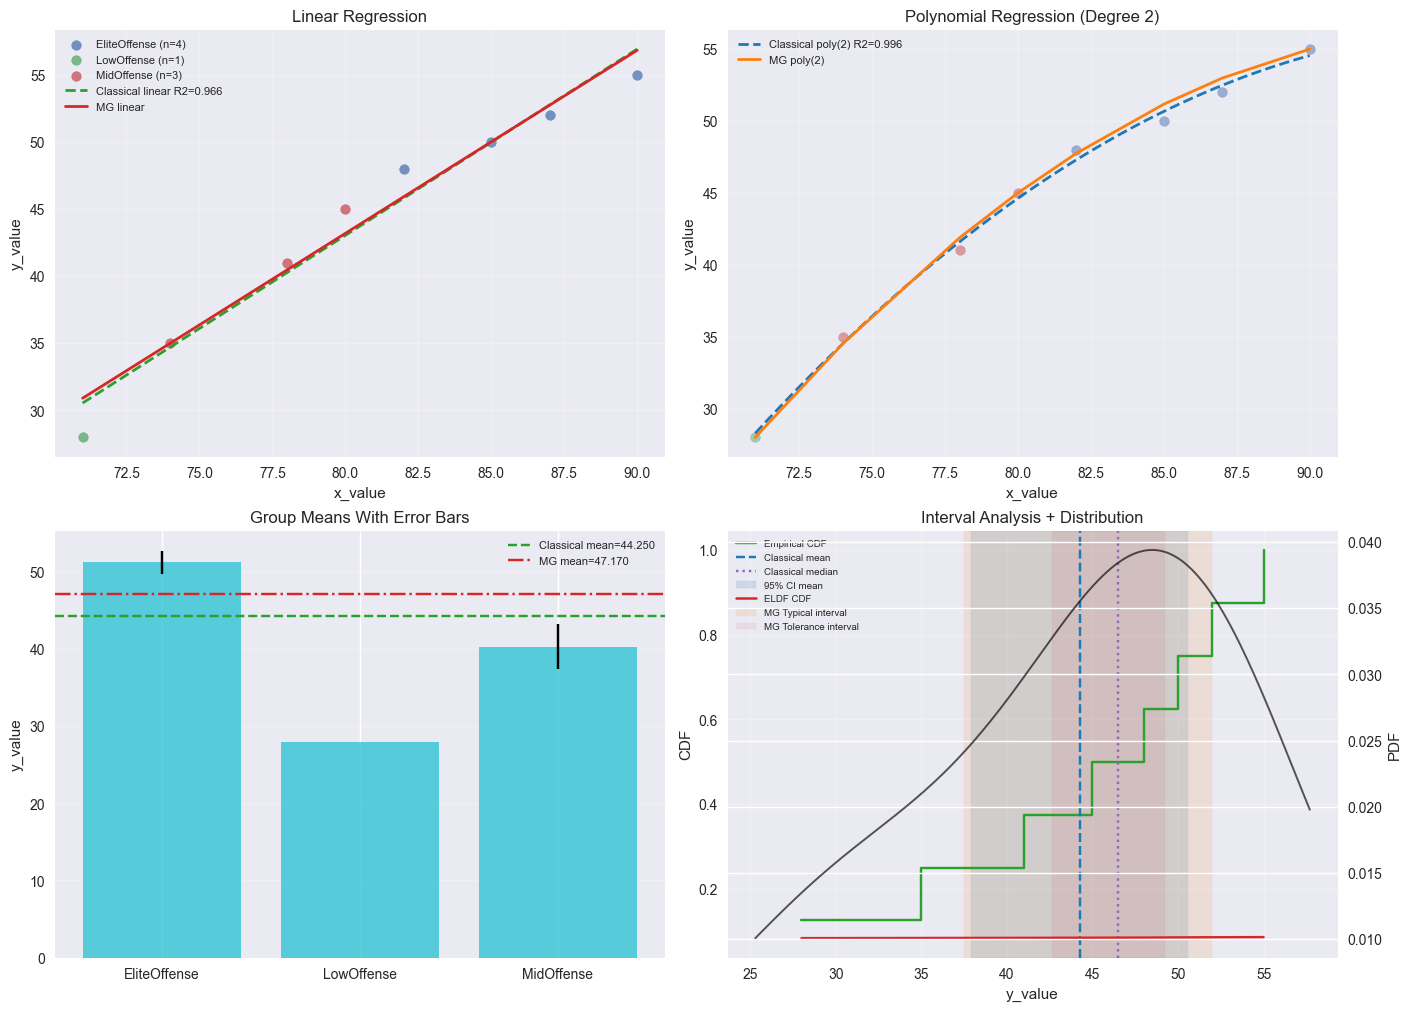

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes

# Panel 1: Linear regression
for g, gdf in df.groupby('group'):
    ax1.scatter(gdf['x_value'], gdf['y_value'], label=f'{g} (n={len(gdf)})', alpha=0.75)

x_grid = np.linspace(np.min(x), np.max(x), 200)
y_grid_lin = lin.predict(x_grid.reshape(-1, 1))
ax1.plot(x_grid, y_grid_lin, '--', color='tab:green', linewidth=2, label=f'Classical linear R2={r2_lin:.3f}')

if mg_available and np.isfinite(y_mg_lin).all():
    order = np.argsort(x)
    ax1.plot(np.asarray(x)[order], np.asarray(y_mg_lin)[order], '-', color='tab:red', linewidth=2, label='MG linear')

ax1.set_title('Linear Regression')
ax1.set_xlabel('x_value')
ax1.set_ylabel('y_value')
ax1.grid(alpha=0.25)
ax1.legend(loc='best', fontsize=8)

# Panel 2: Polynomial regression
for g, gdf in df.groupby('group'):
    ax2.scatter(gdf['x_value'], gdf['y_value'], alpha=0.5)

y_grid_poly = poly_model.predict(x_grid.reshape(-1, 1))
ax2.plot(x_grid, y_grid_poly, '--', color='tab:blue', linewidth=2, label=f'Classical poly(2) R2={r2_poly:.3f}')

if mg_available and np.isfinite(y_mg_poly).any():
    order = np.argsort(x)
    ax2.plot(np.asarray(x)[order], np.asarray(y_mg_poly)[order], '-', color='tab:orange', linewidth=2, label='MG poly(2)')

ax2.set_title('Polynomial Regression (Degree 2)')
ax2.set_xlabel('x_value')
ax2.set_ylabel('y_value')
ax2.grid(alpha=0.25)
ax2.legend(loc='best', fontsize=8)

# Panel 3: Means and error bars
plot_df = group_summary.copy()
plot_df['se'] = plot_df['group_std'] / np.sqrt(plot_df['count'].clip(lower=1))
ax3.bar(plot_df['group'], plot_df['group_mean'], yerr=plot_df['se'].fillna(0), capsize=6, color='tab:cyan', alpha=0.7)
ax3.axhline(mean_y, color='tab:green', linestyle='--', label=f'Classical mean={mean_y:.3f}')
if mg_available and np.isfinite(mg_mean_y):
    ax3.axhline(mg_mean_y, color='tab:red', linestyle='-.', label=f'MG mean={mg_mean_y:.3f}')
ax3.set_title('Group Means With Error Bars')
ax3.set_ylabel('y_value')
ax3.grid(axis='y', alpha=0.25)
ax3.legend(loc='best', fontsize=8)

# Panel 4: Interval analysis and distribution
y_sorted = np.sort(y)
emp_cdf = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
ax4.step(y_sorted, emp_cdf, where='post', color='tab:green', label='Empirical CDF')

ax4.axvline(mean_y, color='tab:blue', linestyle='--', label='Classical mean')
ax4.axvline(median_y, color='tab:purple', linestyle=':', label='Classical median')
if mg_available and np.isfinite(mg_mean_y):
    ax4.axvline(mg_mean_y, color='tab:red', linestyle='-.', label='MG mean')

if np.isfinite(ci_low) and np.isfinite(ci_high):
    ax4.axvspan(ci_low, ci_high, alpha=0.15, color='tab:blue', label='95% CI mean')

if mg_available:
    try:
        eldf = ELDF(flush=False)
        eldf.fit(y)
        x_curve = np.asarray(getattr(eldf, 'di_points', np.sort(y)), dtype=float).reshape(-1)
        cdf_curve = np.asarray(getattr(eldf, 'eldf_points', np.linspace(0, 1, len(x_curve))), dtype=float).reshape(-1)
        order = np.argsort(x_curve)
        ax4.plot(x_curve[order], cdf_curve[order], color='tab:red', linewidth=1.8, label='ELDF CDF')
    except Exception:
        pass

    if np.isfinite(mg_typ_low) and np.isfinite(mg_typ_high):
        ax4.axvspan(mg_typ_low, mg_typ_high, alpha=0.12, color='tab:orange', label='MG Typical interval')
    if np.isfinite(mg_tol_low) and np.isfinite(mg_tol_high):
        ax4.axvspan(mg_tol_low, mg_tol_high, alpha=0.08, color='tab:red', label='MG Tolerance interval')

try:
    x_kde = np.linspace(np.min(y) - 0.1 * np.ptp(y), np.max(y) + 0.1 * np.ptp(y), 250)
    kde = gaussian_kde(y)
    kde_vals = kde(x_kde)
    ax4b = ax4.twinx()
    ax4b.plot(x_kde, kde_vals, color='black', alpha=0.65, linewidth=1.4, label='KDE PDF')
    ax4b.set_ylabel('PDF')
except Exception:
    pass

ax4.set_title('Interval Analysis + Distribution')
ax4.set_xlabel('y_value')
ax4.set_ylabel('CDF')
ax4.grid(alpha=0.25)
ax4.legend(loc='best', fontsize=7)

plt.show()

## Step 5: Side-By-Side Comparison Table
Read this table from top to bottom to compare classical and Machine Gnostics outputs.

In [12]:
comparison = pd.DataFrame([
    {'family': 'central_tendency', 'metric': 'mean_y', 'classical': mean_y, 'machine_gnostics': mg_mean_y},
    {'family': 'central_tendency', 'metric': 'median_y', 'classical': median_y, 'machine_gnostics': mg_median_y},
    {'family': 'association', 'metric': 'correlation', 'classical': corr_all, 'machine_gnostics': mg_corr},
    {'family': 'fit_quality', 'metric': 'linear_score', 'classical': r2_lin, 'machine_gnostics': np.nan if not mg_available else mg_metrics.loc[mg_metrics.metric=='mg_robr2_linear', 'value'].values[0]},
    {'family': 'fit_quality', 'metric': 'poly_score', 'classical': r2_poly, 'machine_gnostics': np.nan if not mg_available else mg_metrics.loc[mg_metrics.metric=='mg_robr2_polynomial_deg2', 'value'].values[0]},
    {'family': 'interval', 'metric': 'low_bound', 'classical': ci_low, 'machine_gnostics': mg_typ_low},
    {'family': 'interval', 'metric': 'high_bound', 'classical': ci_high, 'machine_gnostics': mg_typ_high},
])

comparison.round(5)

,family,metric,classical,machine_gnostics
0,central_tendency,mean_y,44.25000,47.17000
1,central_tendency,median_y,46.50000,46.41400
2,association,correlation,0.98272,0.99509
3,fit_quality,linear_score,0.96575,0.99998
4,fit_quality,poly_score,0.99624,1.00000
5,interval,low_bound,37.92322,37.51137
6,interval,high_bound,50.57678,52.01065


## Step 9: Key Takeaways

- Outcome: strong pooled FT%-wins correlation weakens or can reverse within team-strength tiers.
- Practical lesson: confounding by team quality can mislead tactical inference.
- Machine Gnostics value: subgroup-aware robust analysis gives safer decision signals than pooled correlation alone.
